In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
# Most common genres
genra = df['listed_in'].str.split(', ', expand=True).stack().value_counts().sum()
print(int(genra))

19323


year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
dtype: int64


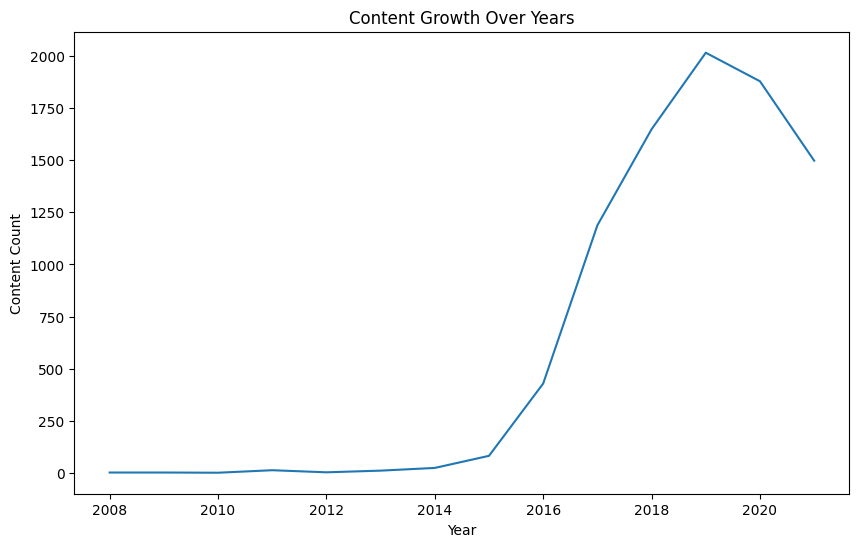

In [15]:
# Analyze content growth over years
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
df['year_added'] = df['date_added'].dt.year
content_growth = df.groupby('year_added').size()
print(content_growth)

plt.figure(figsize=(10, 6))
sns.lineplot(x=content_growth.index, y=content_growth.values)
plt.xlabel('Year')
plt.ylabel('Content Count')
plt.title('Content Growth Over Years')
plt.show()

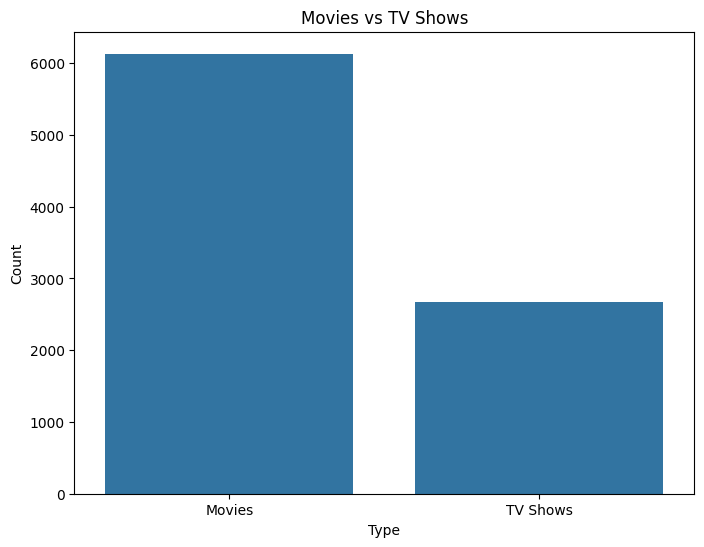

In [16]:
# Compare Movies vs TV Shows
movie_count = df[df['type'] == 'Movie'].shape[0]
tv_show_count = df[df['type'] == 'TV Show'].shape[0]

plt.figure(figsize=(8, 6))
sns.barplot(x=['Movies', 'TV Shows'], y=[movie_count, tv_show_count])
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Movies vs TV Shows')
plt.show()

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
                  ... 
Sudan                1
Panama               1
Uganda               1
East Germany         1
Montenegro           1
Name: count, Length: 127, dtype: int64


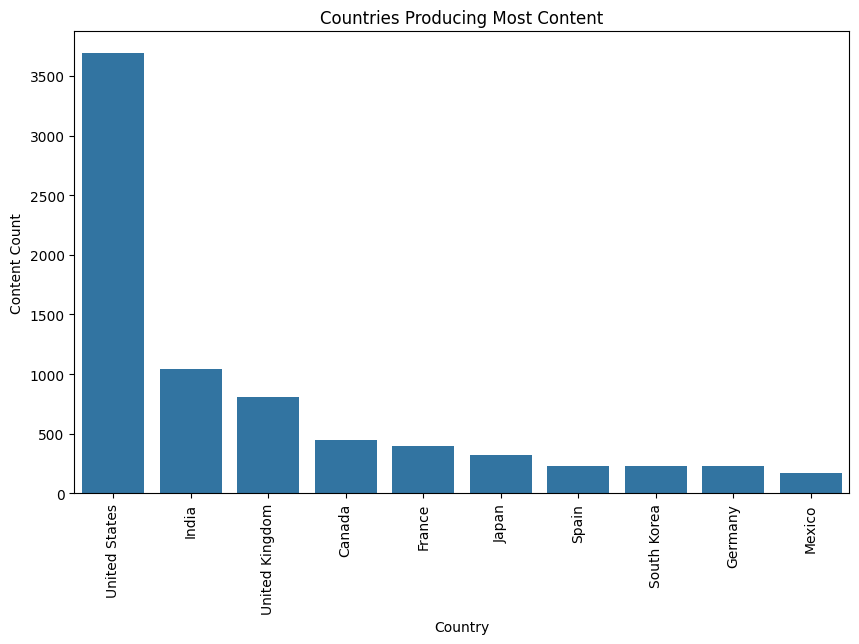

In [19]:
# Find countries producing most content
country_counts = df['country'].str.split(', ').explode().value_counts()
print(country_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_counts.index[:10], y=country_counts.values[:10])
plt.xlabel('Country')
plt.ylabel('Content Count')
plt.title('Countries Producing Most Content')
plt.xticks(rotation=90)
plt.show()

In [12]:
# Analyze ratings distribution
rating_counts = df['rating'].value_counts()
print(rating_counts)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


Visualization

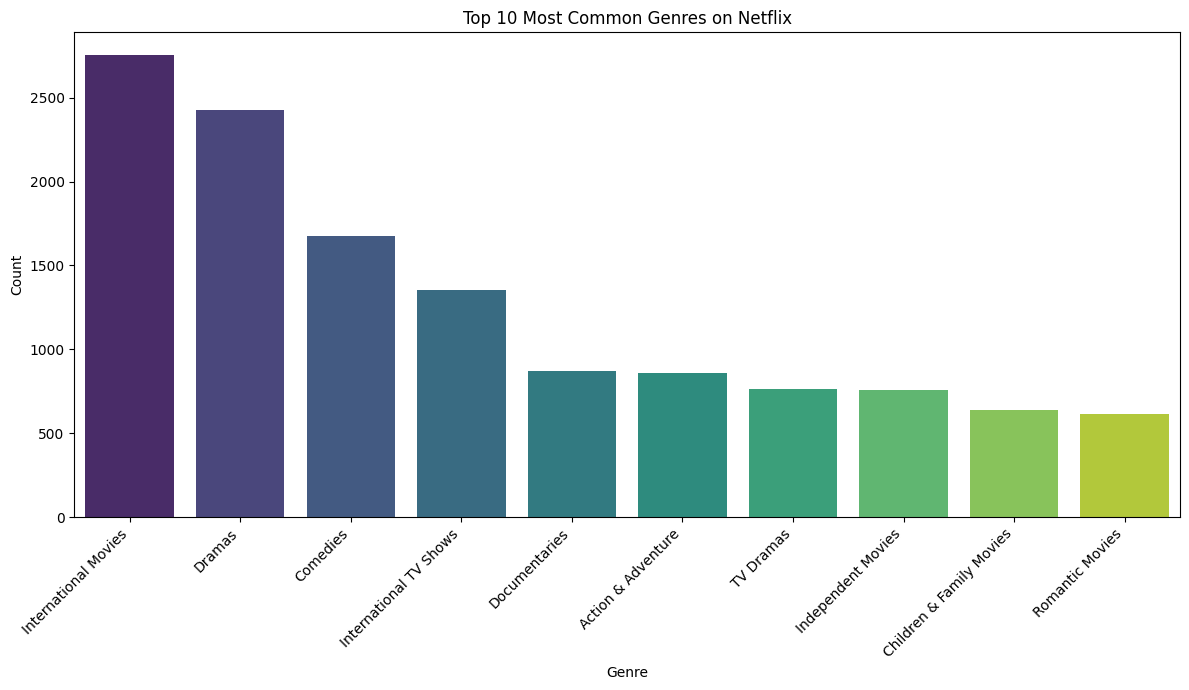

In [21]:
# genre distribution
# Extract individual genres and count their occurrences
genres = df['listed_in'].str.split(', ', expand=True).stack()
genre_counts = genres.value_counts()

# Select the top 10 most common genres
top_10_genres = genre_counts.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_genres.index, y=top_10_genres.values, palette='viridis')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Top 10 Most Common Genres on Netflix')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

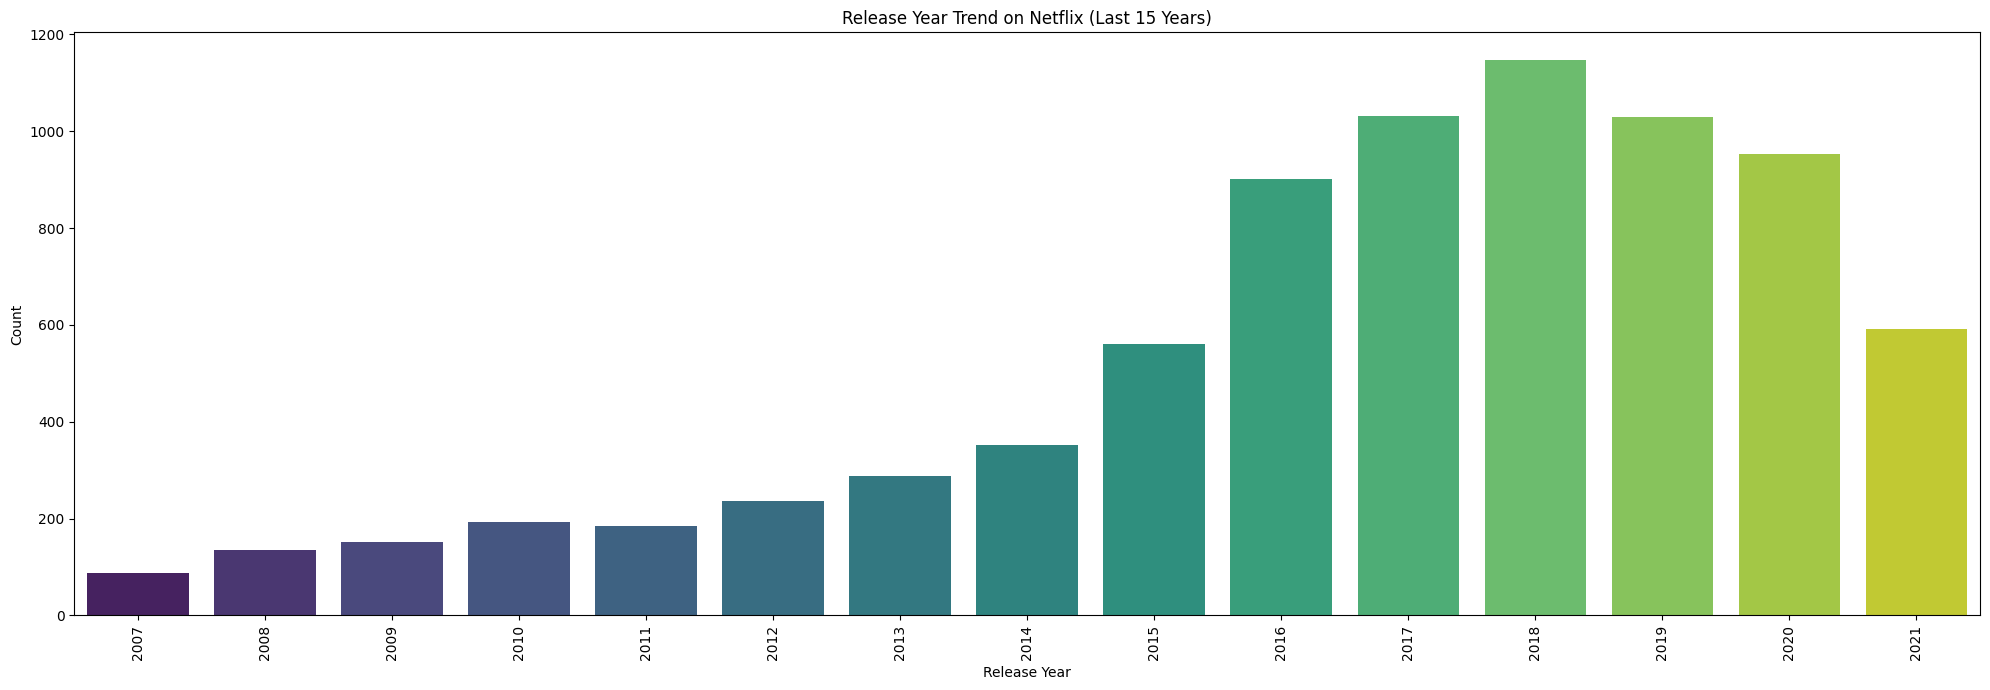

In [25]:
# release year trend

# Calculate the count of content per release year
release_year_counts = df['release_year'].value_counts().sort_index()

# Find the maximum release year in the dataset
max_release_year = df['release_year'].max()

# Determine the start year for the last 15 years (inclusive)
start_year_for_trend = max_release_year - 14 # For a 15-year trend

# Filter the DataFrame to include only content from the last 15 years
df_filtered_recent_years = df[df['release_year'] >= start_year_for_trend]

plt.figure(figsize=(20, 7)) # Adjust figure size for better readability
sns.countplot(data=df_filtered_recent_years, x='release_year', palette='viridis', order=sorted(df_filtered_recent_years['release_year'].unique()))
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.title(f'Release Year Trend on Netflix (Last {int(max_release_year - start_year_for_trend + 1)} Years)')
plt.xticks(rotation=90) # Rotate x-axis labels for better visibility
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

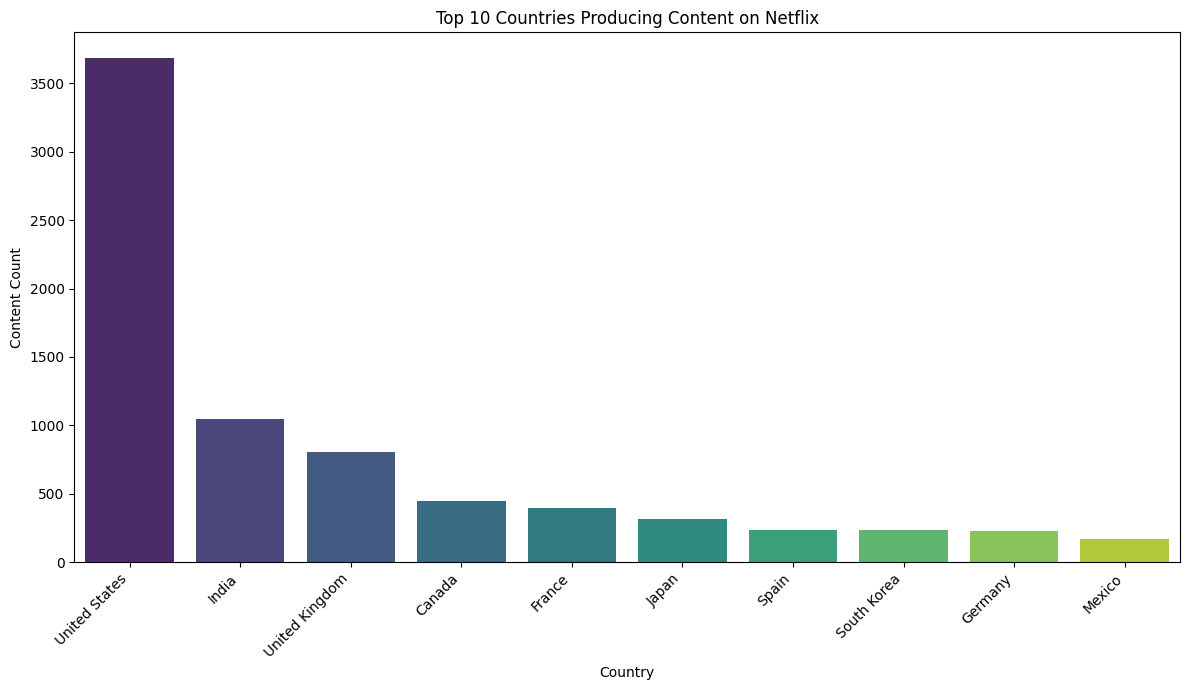

In [28]:
# country-wise content count
# Re-calculating country_counts to ensure it's up-to-date and consistent
country_counts = df['country'].str.split(', ').explode().value_counts()

# Select the top 10 most frequent countries
top_10_countries = country_counts.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')
plt.xlabel('Country')
plt.ylabel('Content Count')
plt.title('Top 10 Countries Producing Content on Netflix')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

In [29]:
# strategic insights for Netflix
print('Invest more in trending genres')
print('Expand content production in high-performing countries')
print('Increase TV show production if engagement is high')
print('Focus on audience-preferred ratings')

Invest more in trending genres
Expand content production in high-performing countries
Increase TV show production if engagement is high
Focus on audience-preferred ratings
